# Portfolio Value-at-Risk: equity and currency risk decomposed

A ruble-based investor holds a 60/40 portfolio of US (NASDAQ 100) and German
(DAX) equities. Because the holdings are denominated in dollars and euros,
the investor carries two distinct risks: the equity markets themselves, and
the currency in which those markets are priced.

This notebook decomposes the portfolio's ruble return into those two pieces,
estimates their volatility and correlation through time with EWMA, and
compares three ways of computing Value-at-Risk over a sample covering four
separate crises.

All of the calculations come from the `quantile_compass` package, so the same
code backs this notebook, the docs and the Streamlit app.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from quantile_compass.data import prepare_dataset
from quantile_compass.returns import PortfolioSpec, decompose_portfolio_returns
from quantile_compass.var import (
    age_weighted_historical_var,
    historical_var,
    parametric_var,
    scale_var_horizon,
)
from quantile_compass.viz import (
    plot_correlation,
    plot_price_levels,
    plot_return_distribution,
    plot_var_comparison,
    plot_volatility,
)
from quantile_compass.volatility import (
    annualize_volatility,
    covariance_matrix,
    ewma_correlation,
    ewma_volatility,
)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Data

Prices come from the `fetch_data` module (run `python -m quantile_compass.fetch_data`
to refresh). `prepare_dataset` trims the sparse early period and repairs the
handful of bad ticks the free data feed carries.

In [2]:
prices = prepare_dataset()
print(f"{prices.index.min().date()} -> {prices.index.max().date()}  ({len(prices):,} rows)")
prices.tail()

2006-05-16 -> 2026-09-11  (4,990 rows)


,NASDAQ100,DAX,USD_RUB,EUR_RUB,SP500,VIX,GOLD
Date,,,,,,,
2026-09-04,"29,544.1504","26,046.4004",86.6342,100.7556,"7,718.6001",14.5300,"4,429.7998"
2026-09-08,"29,507.6992","26,007.6309",85.9439,99.9296,"7,673.5200",15.7200,"4,393.8999"
2026-09-09,"29,421.5508","25,576.4492",85.8502,99.8142,"7,636.3599",16.4600,"4,416.0000"
2026-09-10,"29,103.5098","25,361.1504",84.9980,98.8794,"7,591.7002",17.8400,"4,364.5000"
2026-09-11,"29,368.4395","25,568.5605",83.9491,97.8630,"7,656.9800",15.8400,"4,366.2002"


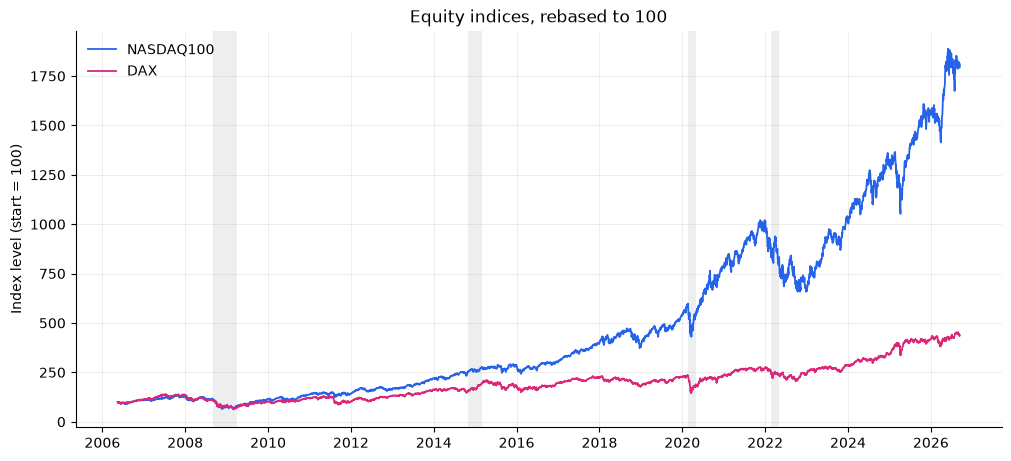

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_price_levels(prices, ["NASDAQ100", "DAX"], ax=ax)
ax.set_title("Equity indices, rebased to 100")
plt.show()

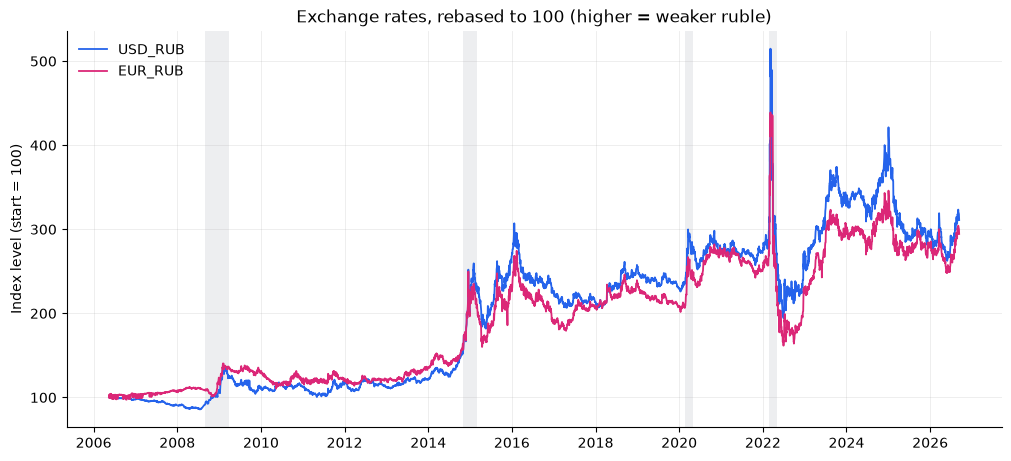

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_price_levels(prices, ["USD_RUB", "EUR_RUB"], ax=ax)
ax.set_title("Exchange rates, rebased to 100 (higher = weaker ruble)")
plt.show()

## 2. Decomposing the portfolio return

In logs the ruble return separates cleanly into an equity part and a currency part:

$$r_t = \underbrace{w_{de}\beta_{de} r^{DAX}_t + w_{us}\beta_{us} r^{NDX}_t}_{\text{equity}}
       + \underbrace{w_{de} r^{EURRUB}_t + w_{us} r^{USDRUB}_t}_{\text{forex}}$$

In [5]:
spec = PortfolioSpec(w_us=0.6, w_de=0.4, beta_us=1.6, beta_de=1.3)
returns = decompose_portfolio_returns(prices, spec=spec)
returns.describe()

,equity,forex,total
count,"4,988.0000","4,988.0000","4,988.0000"
mean,0.0007,0.0002,0.0009
std,0.0184,0.0127,0.0216
min,-0.1613,-0.1286,-0.1792
25%,-0.0072,-0.0042,-0.0093
50%,0.0014,-0.0000,0.0012
75%,0.0097,0.0044,0.0114
max,0.1699,0.2387,0.2075


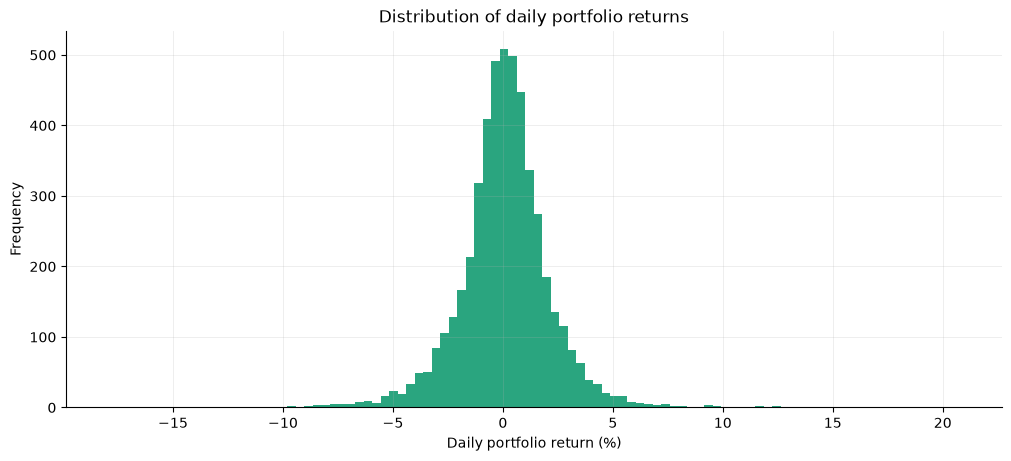

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_return_distribution(returns["total"], ax=ax)
ax.set_title("Distribution of daily portfolio returns")
plt.show()

## 3. EWMA volatility and correlation

Volatility is estimated with the RiskMetrics EWMA recursion at $\lambda = 0.94$.
The recursion is seeded from a burn-in window rather than the full sample, so
each estimate depends only on returns that precede it.

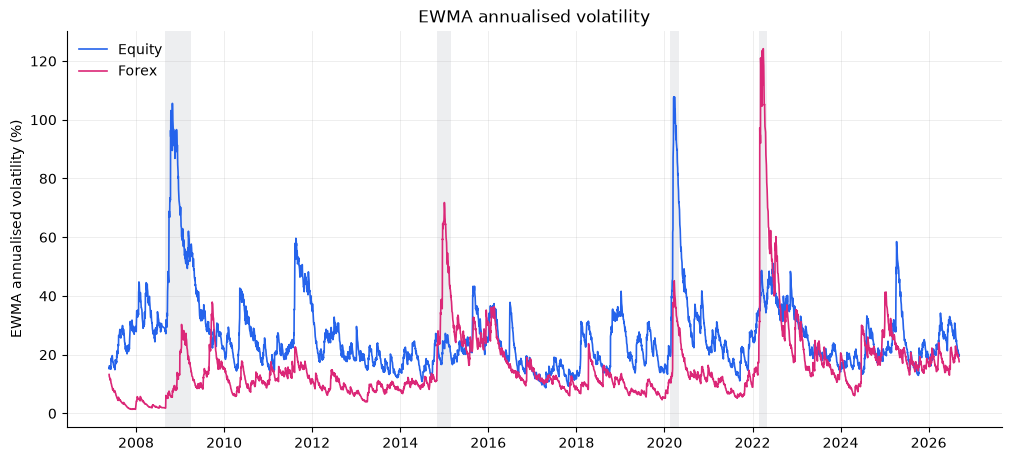

In [7]:
vol_equity = annualize_volatility(ewma_volatility(returns["equity"]))
vol_forex = annualize_volatility(ewma_volatility(returns["forex"]))
correlation = ewma_correlation(returns["equity"], returns["forex"])

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_volatility(vol_equity, vol_forex, ax=ax)
ax.set_title("EWMA annualised volatility")
plt.show()

In [8]:
print(f"Equity vol: mean {vol_equity.mean():.1%}, peak {vol_equity.max():.1%} on {vol_equity.idxmax().date()}")
print(f"Forex  vol: mean {vol_forex.mean():.1%}, peak {vol_forex.max():.1%} on {vol_forex.idxmax().date()}")

Equity vol: mean 26.3%, peak 107.8% on 2020-03-19
Forex  vol: mean 15.8%, peak 124.2% on 2022-03-31


The two components peak in different crises. Equity volatility peaks in the
2008 crisis and again in the COVID crash; currency volatility is comparatively
quiet through both, then dominates in 2014 and 2022 — shocks specific to the
ruble rather than to global equity markets.

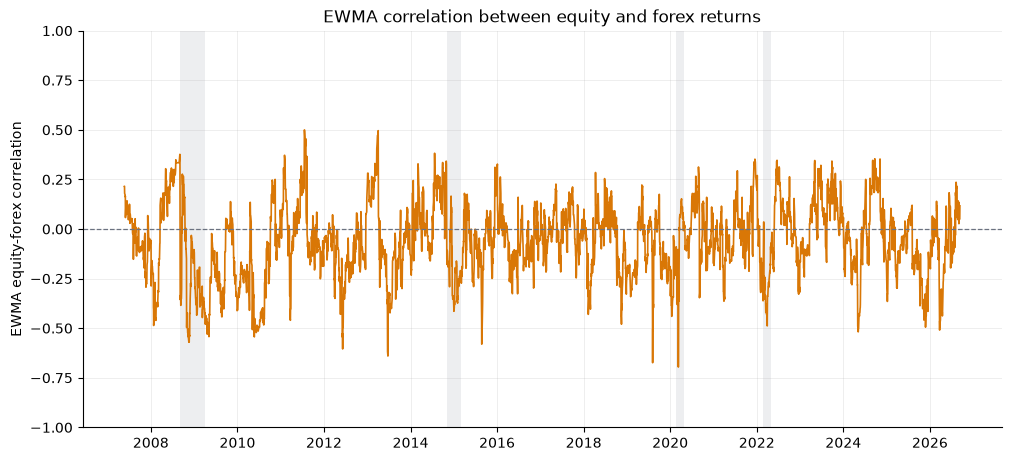

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_correlation(correlation, ax=ax)
ax.set_title("EWMA correlation between equity and forex returns")
plt.show()

In [10]:
print(f"Correlation: mean {correlation.mean():.3f}, range {correlation.min():.3f} to {correlation.max():.3f}")

Correlation: mean -0.064, range -0.696 to 0.500


## 4. Value-at-Risk

Three estimators, all at 99% confidence over one day:

- **Parametric** — assumes normality, driven by the current EWMA covariance, so it
  reacts quickly to recent shocks.
- **Historical** — the empirical quantile of realised returns; no distributional
  assumption, but every observation in the sample counts equally.
- **Age-weighted** — the hybrid of Boudoukh, Richardson and Whitelaw (1998):
  an empirical quantile over exponentially decaying probability weights.

In [11]:
cov = covariance_matrix(returns["equity"], returns["forex"])
cov

,equity,forex
equity,0.0389,0.0041
forex,0.0041,0.0310


In [12]:
var_methods = {
    "Parametric": parametric_var([1, 1], cov),
    "Historical": historical_var(returns["total"]),
    "Age-weighted": age_weighted_historical_var(returns["total"]),
}
for name, value in var_methods.items():
    print(f"{name:14s} 1-day 99% VaR: {value:.2%}   10-day: {scale_var_horizon(value, 10):.2%}")

Parametric     1-day 99% VaR: 4.11%   10-day: 13.00%
Historical     1-day 99% VaR: 5.96%   10-day: 18.85%
Age-weighted   1-day 99% VaR: 2.92%   10-day: 9.24%


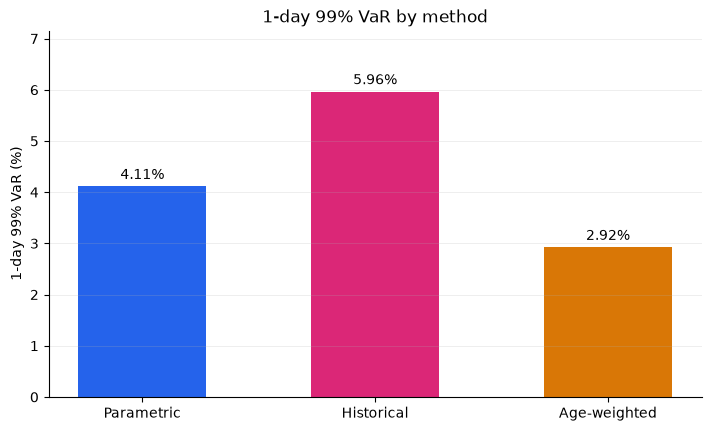

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
plot_var_comparison(var_methods, ax=ax)
ax.set_title("1-day 99% VaR by method")
plt.show()

The spread between the three is the interesting part. Historical VaR is the
highest because the 20-year sample contains crises far more severe than
current conditions, and it weights them as heavily as last week. The
age-weighted estimate is the lowest, because it discounts those distant
crises in favour of the recent, calmer regime. Parametric sits between them.

None of the three is "correct" on its own — they answer slightly different
questions, and the gap between them is itself a measure of how much the
answer depends on that choice.

## 5. Stand-alone component risk

Setting the exposure vector to $[1, 0]$ or $[0, 1]$ isolates each risk factor.

In [14]:
components = {
    "Equity only": parametric_var([1, 0], cov),
    "Forex only": parametric_var([0, 1], cov),
    "Combined": parametric_var([1, 1], cov),
}
for name, value in components.items():
    print(f"{name:14s}: {value:.2%}")

undiversified = components["Equity only"] + components["Forex only"]
benefit = undiversified - components["Combined"]
print(f"\nSum of stand-alone: {undiversified:.2%}")
print(f"Diversification benefit: {benefit:.2%}")

Equity only   : 2.90%
Forex only    : 2.59%
Combined      : 4.11%

Sum of stand-alone: 5.49%
Diversification benefit: 1.38%
